#Label Smoothing vs Normal Training


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 158kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.72MB/s]


Training WITHOUT label smoothing...
Epoch 1, Loss: 323.7149
Epoch 2, Loss: 145.3642
Epoch 3, Loss: 100.2834

Training WITH label smoothing...
Epoch 1, Loss: 786.7146
Epoch 2, Loss: 648.4167
Epoch 3, Loss: 616.5880

Accuracy WITHOUT smoothing: 0.9706000089645386
Accuracy WITH smoothing: 0.9747999906539917


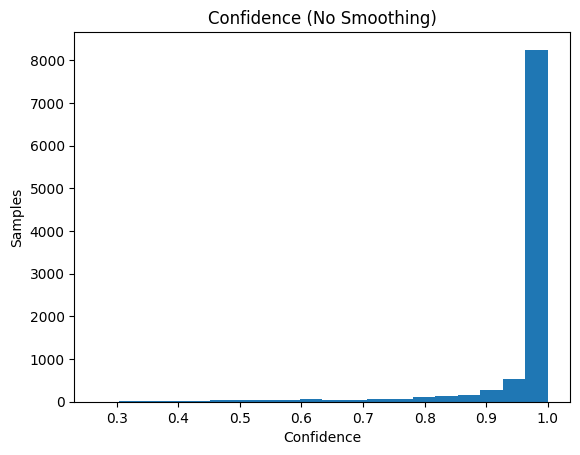

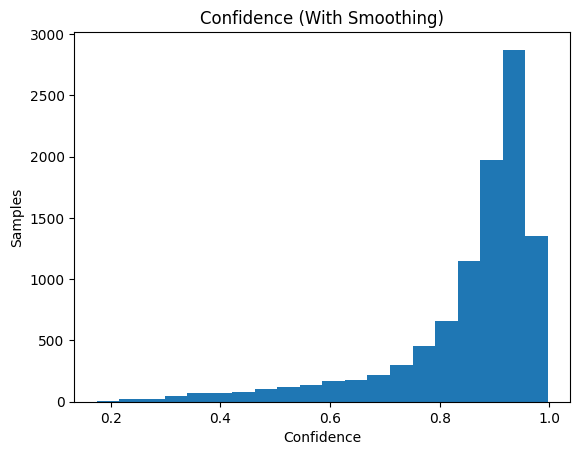

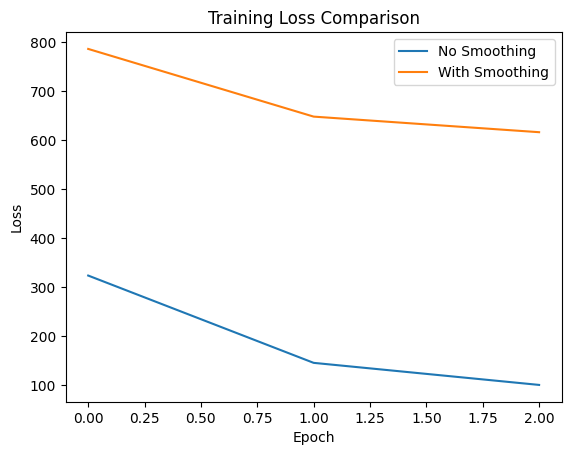

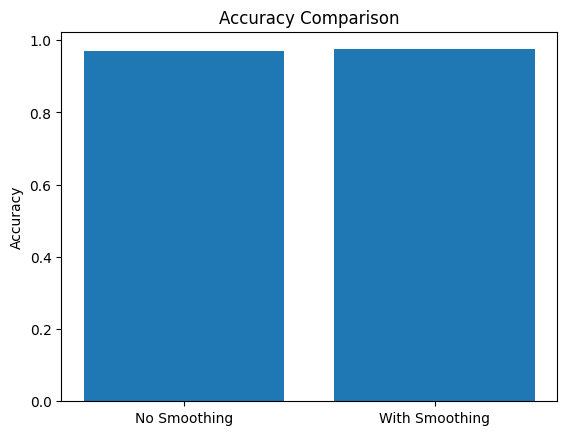

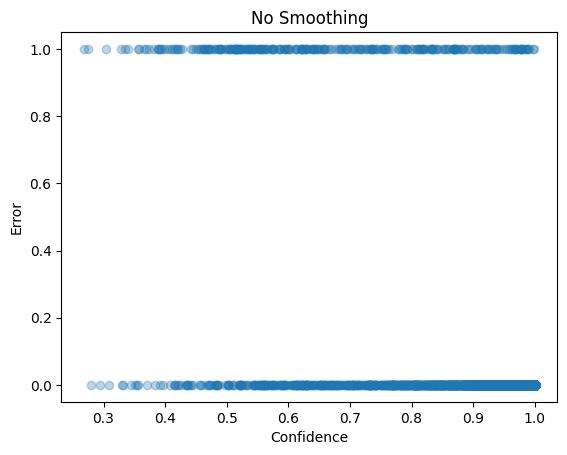

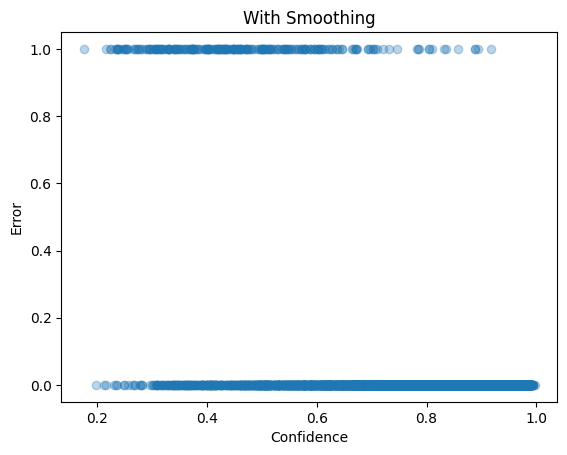

In [1]:
# ===============================
# 1. IMPORTS
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ===============================
# 2. LOAD DATASET (MNIST)
# ===============================
transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# ===============================
# 3. MODEL
# ===============================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# ===============================
# 4. LABEL SMOOTHING LOSS
# ===============================
class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, target):
        num_classes = logits.size(1)
        log_probs = F.log_softmax(logits, dim=1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

# ===============================
# 5. TRAIN FUNCTION
# ===============================
def train_model(model, loss_fn, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return train_losses

# ===============================
# 6. TRAIN TWO MODELS
# ===============================
print("Training WITHOUT label smoothing...")
model_normal = MLP()
loss_normal = nn.CrossEntropyLoss()
losses_normal = train_model(model_normal, loss_normal)

print("\nTraining WITH label smoothing...")
model_smooth = MLP()
loss_smooth = LabelSmoothingLoss(smoothing=0.1)
losses_smooth = train_model(model_smooth, loss_smooth)

# ===============================
# 7. EVALUATION
# ===============================
def get_probs(model):
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in testloader:
            logits = model(images)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)
    probs = F.softmax(logits, dim=1)

    return probs, labels

probs_normal, labels = get_probs(model_normal)
probs_smooth, _ = get_probs(model_smooth)

# ===============================
# 8. ACCURACY FUNCTION
# ===============================
def accuracy(probs, labels):
    preds = torch.argmax(probs, dim=1)
    return (preds == labels).float().mean().item()

acc_normal = accuracy(probs_normal, labels)
acc_smooth = accuracy(probs_smooth, labels)

print("\nAccuracy WITHOUT smoothing:", acc_normal)
print("Accuracy WITH smoothing:", acc_smooth)

# ===============================
# 9. CONFIDENCE HISTOGRAM
# ===============================
def plot_confidence_histogram(probs, title):
    confidences, _ = torch.max(probs, 1)

    plt.figure()
    plt.hist(confidences.numpy(), bins=20)
    plt.xlabel("Confidence")
    plt.ylabel("Samples")
    plt.title(title)
    plt.show()

plot_confidence_histogram(probs_normal, "Confidence (No Smoothing)")
plot_confidence_histogram(probs_smooth, "Confidence (With Smoothing)")

# ===============================
# 10. LOSS CURVE
# ===============================
plt.figure()
plt.plot(losses_normal, label="No Smoothing")
plt.plot(losses_smooth, label="With Smoothing")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ===============================
# 11. ACCURACY BAR CHART
# ===============================
plt.figure()
plt.bar(["No Smoothing", "With Smoothing"], [acc_normal, acc_smooth])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

# ===============================
# 12. CONFIDENCE VS ERROR
# ===============================
def plot_confidence_vs_error(probs, labels, title):
    confidences, predictions = torch.max(probs, 1)
    errors = (~predictions.eq(labels)).float()

    plt.figure()
    plt.scatter(confidences.numpy(), errors.numpy(), alpha=0.3)
    plt.xlabel("Confidence")
    plt.ylabel("Error")
    plt.title(title)
    plt.show()

plot_confidence_vs_error(probs_normal, labels, "No Smoothing")
plot_confidence_vs_error(probs_smooth, labels, "With Smoothing")